In [1]:
# train_classifier.py
import os
import json
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# Labels
SCENE_LABELS = ['city street', 'residential', 'highway', 'gas stations', 'parking', 'tunnel', 'bridge', 'railroad', 'roundabout', 'construction', 'parking lot']
WEATHER_LABELS = ['clear', 'rainy', 'foggy', 'snowy', 'overcast', 'undefined', 'partly cloudy']
TIME_LABELS = ['daytime', 'night', 'dawn/dusk', 'undefined']

# Dataset
class AttributeDataset(Dataset):
    def __init__(self, image_dir, attr_dir, transform=None):
        self.image_dir = image_dir
        self.attr_dir = attr_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        attr_path = os.path.join(self.attr_dir, img_name.replace(".jpg", ".attrs.json"))

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        with open(attr_path, "r") as f:
            attrs = json.load(f)

        scene = SCENE_LABELS.index(attrs["scene"]) if attrs["scene"] in SCENE_LABELS else 0
        weather = WEATHER_LABELS.index(attrs["weather"]) if attrs["weather"] in WEATHER_LABELS else 0
        timeofday = TIME_LABELS.index(attrs["timeofday"]) if attrs["timeofday"] in TIME_LABELS else 0

        return image, torch.tensor(scene), torch.tensor(weather), torch.tensor(timeofday)

# Modelo
class AttributeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        num_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.scene_head = nn.Linear(num_features, len(SCENE_LABELS))
        self.weather_head = nn.Linear(num_features, len(WEATHER_LABELS))
        self.time_head = nn.Linear(num_features, len(TIME_LABELS))

    def forward(self, x):
        feat = self.backbone(x)
        return self.scene_head(feat), self.weather_head(feat), self.time_head(feat)

# Configurações
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10
base_path = "/Users/jorgecunha/PycharmProjects/AI_Detection_Cars/AAU2/Test/yolo_dataset"
image_dir = os.path.join(base_path, "images/train")
attr_dir = os.path.join(base_path, "attrs/train")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = AttributeDataset(image_dir, attr_dir, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttributeClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Treinamento com early stopping
print("🚀 Iniciando treinamento...\n")
best_loss = float('inf')
epochs_no_improve = 0
best_model_path = "attribute_classifier.pt"

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    total_batches = len(loader)
    epoch_start_time = time.time()

    for batch_idx, (imgs, scene, weather, timeofday) in enumerate(loader):
        start_time = time.time()

        imgs = imgs.to(device)
        scene = scene.to(device)
        weather = weather.to(device)
        timeofday = timeofday.to(device)

        scene_out, weather_out, time_out = model(imgs)
        loss = (criterion(scene_out, scene) +
                criterion(weather_out, weather) +
                criterion(time_out, timeofday))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        duration = time.time() - start_time
        total_loss += loss.item()
        remaining = total_batches - (batch_idx + 1)
        print(f"[Epoch {epoch+1}/{EPOCHS}] Batch {batch_idx+1}/{total_batches} - Loss: {loss.item():.4f} - Time: {duration:.2f}s - Remaining Batches: {remaining}")

    avg_loss = total_loss / total_batches
    print(f"✅ Epoch {epoch+1} finalizado - Loss total: {total_loss:.4f} - Média: {avg_loss:.4f} - Tempo: {time.time() - epoch_start_time:.2f}s\n")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), best_model_path)
        print("📦 Novo melhor modelo salvo!")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"⚠️ Sem melhoria. ({epochs_no_improve}/{PATIENCE})\n")
        if epochs_no_improve >= PATIENCE:
            print("⏹️ Early stopping ativado. Encerrando treinamento.")
            break


🚀 Iniciando treinamento...

[Epoch 1/100] Batch 1/37 - Loss: 6.2395 - Time: 1.38s - Remaining Batches: 36
[Epoch 1/100] Batch 2/37 - Loss: 6.0528 - Time: 1.39s - Remaining Batches: 35
[Epoch 1/100] Batch 3/37 - Loss: 5.6989 - Time: 1.36s - Remaining Batches: 34
[Epoch 1/100] Batch 4/37 - Loss: 5.4867 - Time: 1.41s - Remaining Batches: 33
[Epoch 1/100] Batch 5/37 - Loss: 5.2659 - Time: 1.26s - Remaining Batches: 32
[Epoch 1/100] Batch 6/37 - Loss: 5.2904 - Time: 1.26s - Remaining Batches: 31
[Epoch 1/100] Batch 7/37 - Loss: 5.2775 - Time: 1.25s - Remaining Batches: 30
[Epoch 1/100] Batch 8/37 - Loss: 4.8707 - Time: 1.24s - Remaining Batches: 29
[Epoch 1/100] Batch 9/37 - Loss: 4.7912 - Time: 1.26s - Remaining Batches: 28
[Epoch 1/100] Batch 10/37 - Loss: 4.8183 - Time: 1.26s - Remaining Batches: 27
[Epoch 1/100] Batch 11/37 - Loss: 4.4254 - Time: 1.26s - Remaining Batches: 26
[Epoch 1/100] Batch 12/37 - Loss: 4.0033 - Time: 1.26s - Remaining Batches: 25
[Epoch 1/100] Batch 13/37 - Loss:


Precisão no conjunto de teste:
Scene      Accuracy: 0.6849
Weather    Accuracy: 0.6276
Time of Day Accuracy: 0.8937


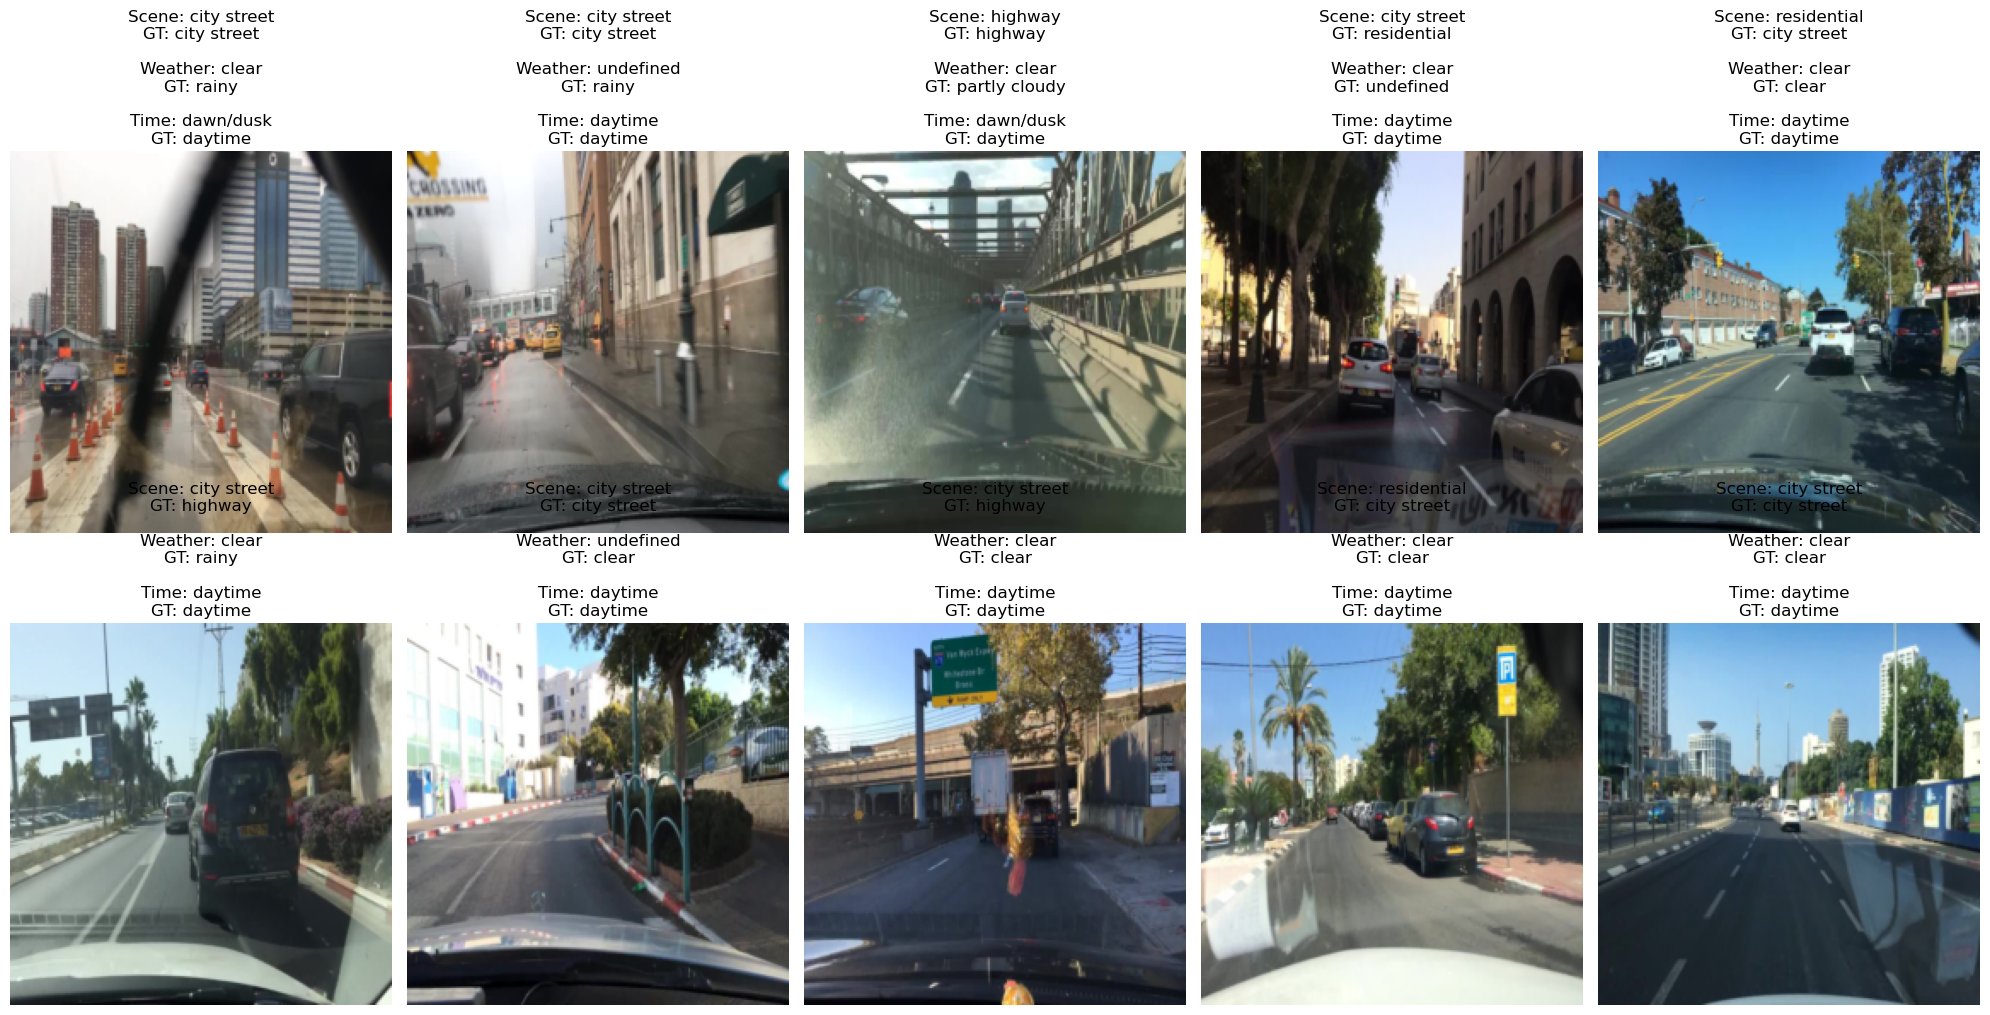

In [2]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Labels
SCENE_LABELS = ['city street', 'residential', 'highway', 'gas stations', 'parking', 'tunnel',
                'bridge', 'railroad', 'roundabout', 'construction', 'parking lot']
WEATHER_LABELS = ['clear', 'rainy', 'foggy', 'snowy', 'overcast', 'undefined', 'partly cloudy']
TIME_LABELS = ['daytime', 'night', 'dawn/dusk', 'undefined']

# Dataset
class AttributeDataset(Dataset):
    def __init__(self, image_dir, attr_dir, transform=None):
        self.image_dir = image_dir
        self.attr_dir = attr_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        attr_path = os.path.join(self.attr_dir, img_name.replace(".jpg", ".attrs.json"))

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        with open(attr_path, "r") as f:
            attrs = json.load(f)

        scene = SCENE_LABELS.index(attrs["scene"]) if attrs["scene"] in SCENE_LABELS else 0
        weather = WEATHER_LABELS.index(attrs["weather"]) if attrs["weather"] in WEATHER_LABELS else 0
        timeofday = TIME_LABELS.index(attrs["timeofday"]) if attrs["timeofday"] in TIME_LABELS else 0

        return image, scene, weather, timeofday

# Modelo
class AttributeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        num_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.scene_head = nn.Linear(num_features, len(SCENE_LABELS))
        self.weather_head = nn.Linear(num_features, len(WEATHER_LABELS))
        self.time_head = nn.Linear(num_features, len(TIME_LABELS))

    def forward(self, x):
        feat = self.backbone(x)
        return self.scene_head(feat), self.weather_head(feat), self.time_head(feat)

# Caminhos e transformações
base_path = "/Users/jorgecunha/PycharmProjects/AI_Detection_Cars/AAU2/Test/yolo_dataset"
image_dir = os.path.join(base_path, "images/validation")
attr_dir = os.path.join(base_path, "attrs/validation")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = AttributeDataset(image_dir, attr_dir, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# Carrega modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttributeClassifier().to(device)
model.load_state_dict(torch.load("attribute_classifier.pt", map_location=device))
model.eval()

# Avaliação
scene_preds, scene_true = [], []
weather_preds, weather_true = [], []
time_preds, time_true = [], []

with torch.no_grad():
    for imgs, scene, weather, timeofday in loader:
        imgs = imgs.to(device)
        out_scene, out_weather, out_time = model(imgs)

        scene_preds.extend(out_scene.argmax(1).cpu().tolist())
        scene_true.extend(scene)
        weather_preds.extend(out_weather.argmax(1).cpu().tolist())
        weather_true.extend(weather)
        time_preds.extend(out_time.argmax(1).cpu().tolist())
        time_true.extend(timeofday)

print("\nPrecisão no conjunto de teste:")
print(f"Scene      Accuracy: {accuracy_score(scene_true, scene_preds):.4f}")
print(f"Weather    Accuracy: {accuracy_score(weather_true, weather_preds):.4f}")
print(f"Time of Day Accuracy: {accuracy_score(time_true, time_preds):.4f}")

# 🔍 Visualização das predições
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

# Pega um batch de imagens aleatórias
example_loader = DataLoader(dataset, batch_size=10, shuffle=True)
imgs, true_scene, true_weather, true_time = next(iter(example_loader))
imgs = imgs.to(device)

with torch.no_grad():
    pred_scene, pred_weather, pred_time = model(imgs)
    pred_scene = pred_scene.argmax(1).cpu()
    pred_weather = pred_weather.argmax(1).cpu()
    pred_time = pred_time.argmax(1).cpu()

imgs = imgs.cpu()

plt.figure(figsize=(20, 10))
for i in range(len(imgs)):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy().clip(0, 1)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Scene: {SCENE_LABELS[pred_scene[i]]}\n" +
        f"GT: {SCENE_LABELS[true_scene[i]]}\n\n" +
        f"️Weather: {WEATHER_LABELS[pred_weather[i]]}\n" +
        f"GT: {WEATHER_LABELS[true_weather[i]]}\n\n" +
        f"Time: {TIME_LABELS[pred_time[i]]}\n" +
        f"GT: {TIME_LABELS[true_time[i]]}"
    )

plt.tight_layout()
plt.show()
